# Montaje Modelos Aprendizaje Continuo

### Imports de librerias y csv

In [ ]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

sys.path.append(os.path.abspath(".."))
ruta_datos = "../Datos_preparados_iomt2024"


x_train_binario = pd.read_csv(f"{ruta_datos}/binario_train_X.csv")
y_train_binario = pd.read_csv(f"{ruta_datos}/binario_train_Y.csv").squeeze()

x_val_binario = pd.read_csv(f"{ruta_datos}/binario_val_X.csv")
y_val_binario = pd.read_csv(f"{ruta_datos}/binario_val_Y.csv").squeeze()

x_test_known_binario = pd.read_csv(f"{ruta_datos}/binario_test_known_X.csv")
y_test_known_binario = pd.read_csv(f"{ruta_datos}/binario_test_known_Y.csv").squeeze()

x_test_zeroday_binario = pd.read_csv(f"{ruta_datos}/binario_test_zeroday_X.csv")
y_test_zeroday_binario = pd.read_csv(f"{ruta_datos}/binario_test_zeroday_Y.csv").squeeze()

x_train_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_train_X.csv")
y_train_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_train_Y.csv").squeeze()

x_val_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_val_X.csv")
y_val_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_val_Y.csv").squeeze()

x_test_known_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_known_X.csv")
y_test_known_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_known_Y.csv").squeeze()

x_test_zeroday_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_zeroday_X.csv")
y_test_zeroday_multiclase = pd.read_csv(f"{ruta_datos}/multiclase_test_zeroday_Y.csv").squeeze()

#UNDERSAMPLING 1:1

# 1-Unimos X e Y para poder muestrear comodamente
df_train_binario = x_train_binario.copy()
df_train_binario["Binary_label"] = y_train_binario.values

# 2-Separamos clases
df_benigno = df_train_binario[df_train_binario["Binary_label"] == 0].copy()
df_ataque = df_train_binario[df_train_binario["Binary_label"] == 1].copy()

# 3-Undersampling de la clase mayoritaria (ataques)
df_ataque_muestras = df_ataque.sample(n=len(df_benigno), random_state=19)

# 4-Unimos benignos + ataques muestreados
df_train = pd.concat([df_benigno, df_ataque_muestras], axis=0)

# 5-Mezclamos filas
df_train = df_train.sample(frac=1, random_state=19).reset_index(drop=True)

# 6-Volvemos a separar X e Y
x_train_binario_undersampling = df_train.drop(columns=["Binary_label"])
y_train_binario_undersampling = df_train["Binary_label"]

print("\nDistribución train binario con undersampling:")
print(y_train_binario_undersampling.value_counts())
print("\nTamaño de X:", x_train_binario_undersampling.shape)
print("Tamaño de Y:", y_train_binario_undersampling.shape)


Distribución train binario con undersampling:
Binary_label
0    17362
1    17362
Name: count, dtype: int64

Tamaño de X: (34724, 38)
Tamaño de Y: (34724,)


## Adaptative Random Forest

In [6]:
from Scripts_modelos_supervisados.AdaptiveRandomForest import construccion_arf_binario, entrenar_arf_binario, actualizar_arf_binario, evaluar_arf_binario 
from sklearn.model_selection import train_test_split
carpeta_salida_arf = "Resultados_Modelos_Continuos/AdaptativeRandomForest"
os.makedirs(carpeta_salida_arf, exist_ok=True)
from sklearn.model_selection import train_test_split

### Clasificador Binario


==== ADAPTIVE RANDOM FOREST - VALIDACION - BINARIO ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.51      1.00      0.67      1929
           1       1.00      1.00      1.00    652147

    accuracy                           1.00    654076
   macro avg       0.75      1.00      0.83    654076
weighted avg       1.00      1.00      1.00    654076



,precision,recall,f1-score,support
0,0.5052,0.9984,0.6710,1929.0000
1,1.0000,0.9971,0.9985,652147.0000
accuracy,0.9971,0.9971,0.9971,0.9971
macro avg,0.7526,0.9978,0.8348,654076.0000
weighted avg,0.9985,0.9971,0.9976,654076.0000



 Matriz de confusion - Validacion - Binario:

[[  1926      3]
 [  1886 650261]]

Area bajo la curva ROC (AUC-ROC) - Validacion - Binario: 1.000

==== ADAPTIVE RANDOM FOREST - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test known - Binario:

              precision    recall  f1-score   support

           0       0.70      0.42      0.52     37604
           1       0.99      1.00      0.99   1984514

    accuracy                           0.99   2022118
   macro avg       0.84      0.71      0.76   2022118
weighted avg       0.98      0.99      0.98   2022118



,precision,recall,f1-score,support
0,0.6962,0.4201,0.5240,3.760400e+04
1,0.9891,0.9965,0.9928,1.984514e+06
accuracy,0.9858,0.9858,0.9858,9.858000e-01
macro avg,0.8427,0.7083,0.7584,2.022118e+06
weighted avg,0.9836,0.9858,0.9841,2.022118e+06



 Matriz de confusion - Test known - Binario:

[[  15799   21805]
 [   6893 1977621]]

Area bajo la curva ROC (AUC-ROC) - Test known - Binario: 0.985


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

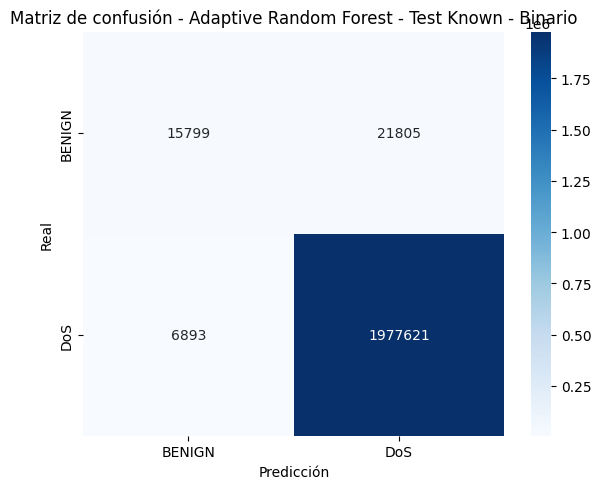


==== ADAPTIVE RANDOM FOREST - TEST ZERODAY - BINARIO - ANTES DE ACTUALIZACION DE DATOS ====
Informe de clasificacion - Test ZeroDay - Binario:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     49209

    accuracy                           1.00     49209
   macro avg       0.50      0.50      0.50     49209
weighted avg       1.00      1.00      1.00     49209



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9971,0.9985,49209.0000
accuracy,0.9971,0.9971,0.9971,0.9971
macro avg,0.5000,0.4985,0.4993,49209.0000
weighted avg,1.0000,0.9971,0.9985,49209.0000



 Matriz de confusion - Test ZeroDay - Binario

[[    0     0]
 [  143 49066]]

No se pudo calcular el area bajo la curva ROC


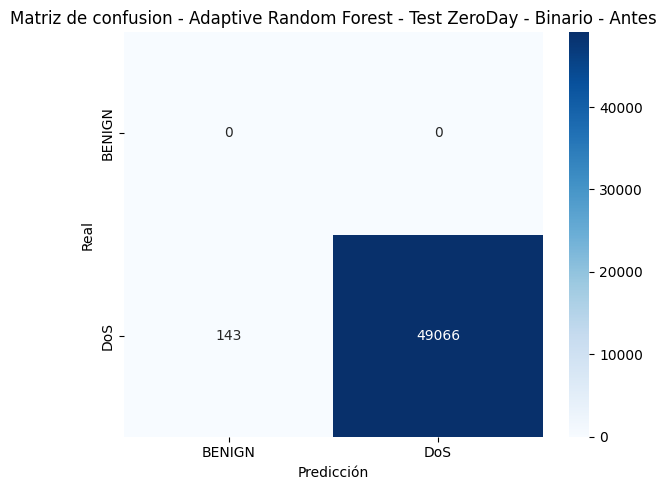

Tasa de detección de ataques ZeroDay antes de actualizacion - Binario - Antes: 0.9971

==== ADAPTIVE RANDOM FOREST - TEST ZERODAY - BINARIO - DESPUES DE ACTUALIZACION DE DATOS ====
Informe de clasificacion - Test ZeroDay - Binario - Despues:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      1.00      1.00     49209

    accuracy                           1.00     49209
   macro avg       0.50      0.50      0.50     49209
weighted avg       1.00      1.00      1.00     49209



,precision,recall,f1-score,support
0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,49209.0
accuracy,1.0,1.0,1.0,1.0
macro avg,0.5,0.5,0.5,49209.0
weighted avg,1.0,1.0,1.0,49209.0



 Matriz de confusion - Test ZeroDay - Binario - Despues

[[    0     0]
 [    0 49209]]

No se pudo calcular el area bajo la curva ROC


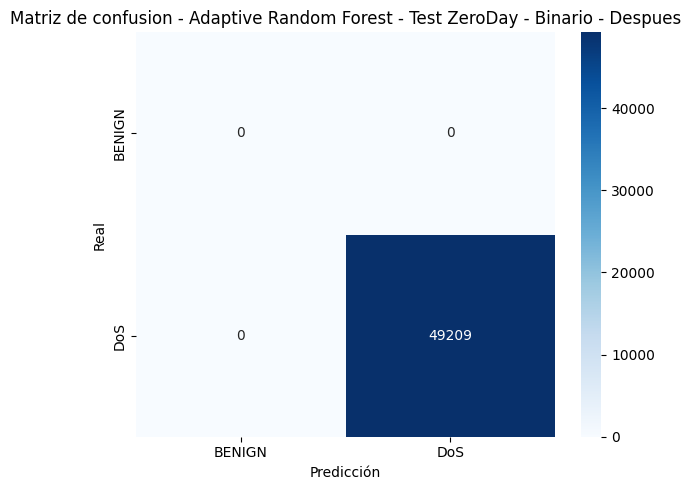

Tasa de detección de ataques ZeroDay antes de actualizacion - Binario: 1.0000

==== COMPARACION APRENDIZAJE CONTINUO ====
Tasa de deteccion ZeroDay antes de actualizacion: 0.9971
Tasa de deteccion ZeroDay despues de actualizacion: 1.0000
Variacion de la tasa de deteccion de ataques ZeroDay tras actualizacion incremental: +0.0029


In [7]:
arf_constructor_modelo_binario = construccion_arf_binario(n_models=10, max_features="sqrt", lambda_value=6, grace_period=50, split_criterion="info_gain", leaf_prediction="nba", seed=19)

arf_modelo_binario = entrenar_arf_binario(arf_constructor_modelo_binario, x_train_binario_undersampling, y_train_binario_undersampling)

# VALIDACION
print("\n==== ADAPTIVE RANDOM FOREST - VALIDACION - BINARIO ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, auc_val_binario = evaluar_arf_binario(
    arf_modelo_binario,
    x_val_binario,
    y_val_binario,
    carpeta_salida_arf,
    "roc_arf_val_binario.png"
)
print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)
display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("\n Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
    
if not np.isnan(auc_val_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Validacion - Binario: {auc_val_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

# TEST KNOWN
print("\n==== ADAPTIVE RANDOM FOREST - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, auc_test_known_binario = evaluar_arf_binario(
    arf_modelo_binario,
    x_test_known_binario,
    y_test_known_binario,
    carpeta_salida_arf,
    "roc_arf_test_known_binario.png"
)
print("Informe de clasificacion - Test known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("\n Matriz de confusion - Test known - Binario:\n")
print(matriz_test_known_binario)
    
if not np.isnan(auc_test_known_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test known - Binario: {auc_test_known_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test Known
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Adaptive Random Forest - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_arf, "matriz_confusion_arf_test_known_binario.png"))
plt.show()

#DIVISION DE TEST ZERODAY PARA EXPERIMENTO DE APRENDIZAJE CONTINUO
x_test_zeroday_actualizacion, x_test_zeroday_evaluacion, y_test_zeroday_actualizacion, y_test_zeroday_evaluacion = train_test_split(x_test_zeroday_binario, y_test_zeroday_binario, test_size=0.5, random_state=19)

# TEST ZERODAY
print("\n==== ADAPTIVE RANDOM FOREST - TEST ZERODAY - BINARIO - ANTES DE ACTUALIZACION DE DATOS ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, auc_test_zeroday_binario = evaluar_arf_binario(
    arf_modelo_binario,
    x_test_zeroday_evaluacion,
    y_test_zeroday_evaluacion,
    carpeta_salida_arf, 
    "roc_arf_test_zeroday_binario_antes.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario\n")
print(matriz_test_zeroday_binario)
    
if not np.isnan(auc_test_zeroday_binario):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Adaptive Random Forest - Test ZeroDay - Binario - Antes")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_arf, "matriz_confusion_arf_test_zeroday_binario_antes.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario[1, 1]
fn_zeroday = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_bal = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay antes de actualizacion - Binario - Antes: {tasa_deteccion_zeroday_bal:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

#ZERO DAY - APRENDIZAJE CONTINUO
arf_modelo_binario_actualizado = actualizar_arf_binario(arf_modelo_binario, x_test_zeroday_actualizacion, y_test_zeroday_actualizacion)

print("\n==== ADAPTIVE RANDOM FOREST - TEST ZERODAY - BINARIO - DESPUES DE ACTUALIZACION DE DATOS ====")
reporte_texto_test_zeroday_binario_despues, reporte_dict_test_zeroday_binario_despues, matriz_test_zeroday_binario_despues, auc_test_zeroday_binario_despues = evaluar_arf_binario(
    arf_modelo_binario_actualizado,
    x_test_zeroday_evaluacion,
    y_test_zeroday_evaluacion,
    carpeta_salida_arf, 
    "roc_arf_test_zeroday_binario_despues.png"
)
print("Informe de clasificacion - Test ZeroDay - Binario - Despues:\n")
print(reporte_texto_test_zeroday_binario_despues)
display(pd.DataFrame(reporte_dict_test_zeroday_binario_despues).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario - Despues\n")
print(matriz_test_zeroday_binario_despues)
    
if not np.isnan(auc_test_zeroday_binario_despues):
    print(f"\nArea bajo la curva ROC (AUC-ROC) - Test ZeroDay - Binario: {auc_test_zeroday_binario_despues:.3f}")
else:
    print("\nNo se pudo calcular el area bajo la curva ROC") 

#Matriz de confusion binario - Test ZeroDay
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario_despues,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Adaptive Random Forest - Test ZeroDay - Binario - Despues")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_arf, "matriz_confusion_arf_test_zeroday_binario_antes.png"))
plt.show()

#Tasa de deteccion de ataques ZeroDay en clasificador binario
tp_zeroday = matriz_test_zeroday_binario_despues[1, 1]
fn_zeroday = matriz_test_zeroday_binario_despues[1, 0]

if (tp_zeroday + fn_zeroday) > 0:
    tasa_deteccion_zeroday_despues = tp_zeroday / (tp_zeroday + fn_zeroday)
    print(f"Tasa de detección de ataques ZeroDay antes de actualizacion - Binario: {tasa_deteccion_zeroday_despues:.4f}")
else:
    print("No fue posible calcular la tasa de detección de ataques ZeroDay para clasificador binario.")

print("\n==== COMPARACION APRENDIZAJE CONTINUO ====")

print(f"Tasa de deteccion ZeroDay antes de actualizacion: {tasa_deteccion_zeroday_bal:.4f}")
print(f"Tasa de deteccion ZeroDay despues de actualizacion: {tasa_deteccion_zeroday_despues:.4f}")

variacion = (tasa_deteccion_zeroday_despues - tasa_deteccion_zeroday_bal)

print(f"Variacion de la tasa de deteccion de ataques ZeroDay tras actualizacion incremental: {variacion:+.4f}")

### K-Means mini Batch

In [8]:
from Scripts_modelos_no_supervisados.kmeans_continuo import construccion_minibatch_kmeans_pipeline, seleccionar_mejor_k_por_silhouette_minibatch, crear_mapeo_cluster_clase, actualizar_minibatch_kmeans, evaluar_minibatch_kmeans_binario

carpeta_salida_minibatch_kmeans = "Resultados_Modelos_Continuos/MiniBatchKMeans"
os.makedirs(carpeta_salida_minibatch_kmeans, exist_ok= True)

#### Clasificador Binario


Distribución validación balanceada para mapping K-Means:
Binary_label
1    1929
0    1929
Name: count, dtype: int64

Tamaño de X: (3858, 38)
Tamaño de Y: (3858,)
Mapeo Binario: {0: np.int64(0), 1: np.int64(1)}

==== MINIBATCH K-MEANS - VALIDACION (BINARIO) ====
Informe de clasificacion - Validacion - Binario:

              precision    recall  f1-score   support

           0       0.02      1.00      0.04      1929
           1       1.00      0.86      0.93    652147

    accuracy                           0.86    654076
   macro avg       0.51      0.93      0.48    654076
weighted avg       1.00      0.86      0.92    654076



,precision,recall,f1-score,support
0,0.0209,1.0000,0.0409,1929.0000
1,1.0000,0.8614,0.9256,652147.0000
accuracy,0.8618,0.8618,0.8618,0.8618
macro avg,0.5104,0.9307,0.4832,654076.0000
weighted avg,0.9971,0.8618,0.9229,654076.0000


Matriz de confusion - Validacion - Binario:

[[  1929      0]
 [ 90370 561777]]
Adjusted Rand Index (ARI) - Validacion - Binario: 0.0297
Silhouette Score: 0.1892

Mapeo cluster -> clase: 
{0: np.int64(0), 1: np.int64(1)}

==== MINIBATCH K-MEANS - TEST KNOWN - BINARIO ====
Informe de clasificacion - Test Known - Binario:

              precision    recall  f1-score   support

           0       0.04      0.92      0.08     37604
           1       1.00      0.63      0.77   1984514

    accuracy                           0.63   2022118
   macro avg       0.52      0.77      0.43   2022118
weighted avg       0.98      0.63      0.76   2022118



,precision,recall,f1-score,support
0,0.0444,0.9160,0.0848,3.760400e+04
1,0.9975,0.6268,0.7699,1.984514e+06
accuracy,0.6322,0.6322,0.6322,6.322000e-01
macro avg,0.5210,0.7714,0.4273,2.022118e+06
weighted avg,0.9797,0.6322,0.7571,2.022118e+06


Matriz de confusion - Test Known - Binario:

[[  34446    3158]
 [ 740591 1243923]]
Adjusted Rand Index (ARI) - Test Known - Binario: 0.0204
Silhouette Score: 0.2414

Mapeo cluster -> clase: 
{0: np.int64(0), 1: np.int64(1)}


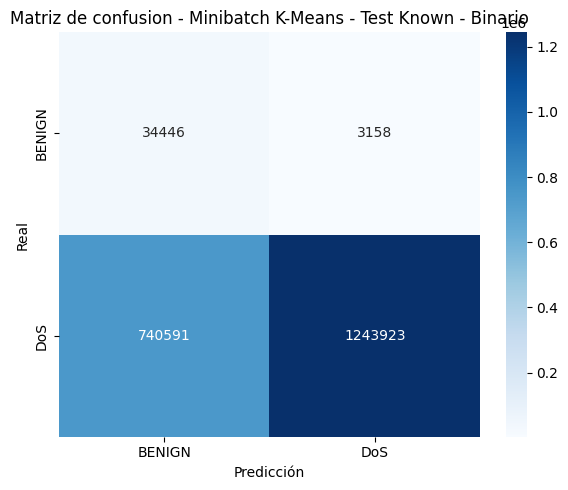


==== MINIBATCH K-MEANS - TEST ZERODAY - BINARIO - ANTES DE ACTUALIZACION DE DATOS ====
Informe de clasificacion - Test ZeroDay - Binario - Antes:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      0.99     49209

    accuracy                           0.99     49209
   macro avg       0.50      0.49      0.50     49209
weighted avg       1.00      0.99      0.99     49209



,precision,recall,f1-score,support
0,0.0000,0.0000,0.0000,0.0000
1,1.0000,0.9897,0.9948,49209.0000
accuracy,0.9897,0.9897,0.9897,0.9897
macro avg,0.5000,0.4948,0.4974,49209.0000
weighted avg,1.0000,0.9897,0.9948,49209.0000



 Matriz de confusion - Test ZeroDay - Binario - Antes

[[    0     0]
 [  507 48702]]
Adjusted Rand Index (ARI) - Test ZeroDay - Binario - Antes: 0.0000
Silhouette Score - Test ZeroDay - Antes: 0.9286

Mapeo cluster -> clase: 
{0: np.int64(0), 1: np.int64(1)}


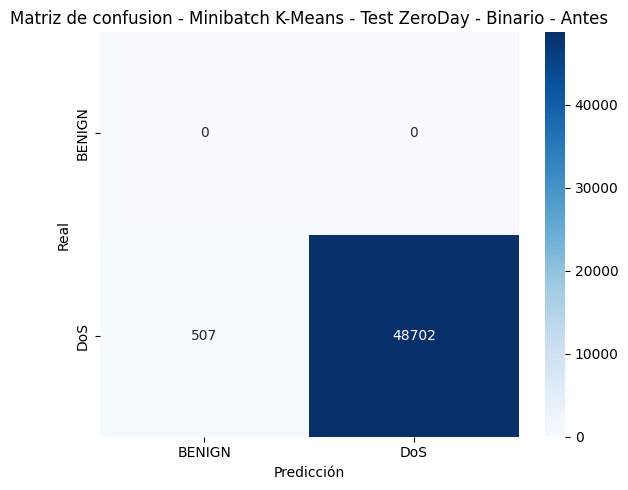

Tasa de detección ataques ZeroDay - Binario - Antes: 0.9897

==== MINIBATCH K-MEANS - TEST ZERODAY - BINARIO - DESPUES DE ACTUALIZACION DE DATOS ====
Informe de clasificacion - Test ZeroDay - Binario - Despues:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      0.99     49209

    accuracy                           0.99     49209
   macro avg       0.50      0.49      0.50     49209
weighted avg       1.00      0.99      0.99     49209



,precision,recall,f1-score,support
0,0.000,0.000,0.000,0.000
1,1.000,0.988,0.994,49209.000
accuracy,0.988,0.988,0.988,0.988
macro avg,0.500,0.494,0.497,49209.000
weighted avg,1.000,0.988,0.994,49209.000



 Matriz de confusion - Test ZeroDay - Binario - Despues

[[    0     0]
 [  589 48620]]
Adjusted Rand Index (ARI) - Test ZeroDay - Binario - Despues: 0.0000
Silhouette Score - Test ZeroDay - Despues: 0.9206

Mapeo cluster -> clase: 
{0: np.int64(0), 1: np.int64(1)}


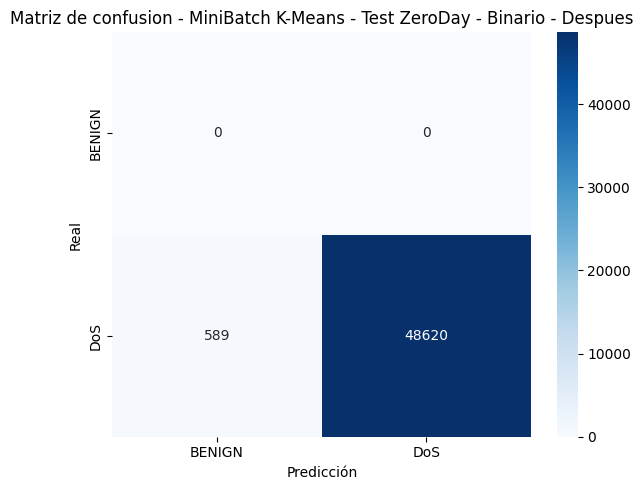

Tasa de detección ataques ZeroDay - Binario - Despues: 0.9880

==== COMPARACION APRENDIZAJE CONTINUO - MINIBATCH K-MEANS ====
Tasa de deteccion ZeroDay antes de actualizacion: 0.9897
Tasa de deteccion ZeroDay despues de actualizacion: 0.9880
Variacion de la tasa de deteccion de ataques ZeroDay tras actualizacion incremental: -0.0017


In [9]:
#mejor_k_binario, silhouette_val_binario = seleccionar_mejor_k_por_silhouette_minibatch(x_train_binario, x_val_binario, k_candidates=(2,3,4,5,6,8,10), random_state=19, n_init=10, sample_size=5000, batch_size=1024)

#UNDERSAMPLING 1:1 PARA MAPPING DE K-MEANS
df_val_binario = x_val_binario.copy()
df_val_binario["Binary_label"] = y_val_binario.values

df_val_benigno = df_val_binario[df_val_binario["Binary_label"] == 0].copy()
df_val_ataque = df_val_binario[df_val_binario["Binary_label"] == 1].copy()

df_val_ataque_muestras = df_val_ataque.sample(
    n=len(df_val_benigno),
    random_state=19
)

df_val_mapping = pd.concat([df_val_benigno, df_val_ataque_muestras], axis=0)

df_val_mapping = df_val_mapping.sample(frac=1, random_state=19).reset_index(drop=True)

x_val_mapping_binario = df_val_mapping.drop(columns=["Binary_label"])
y_val_mapping_binario = df_val_mapping["Binary_label"]

print("\nDistribución validación balanceada para mapping K-Means:")
print(y_val_mapping_binario.value_counts())
print("\nTamaño de X:", x_val_mapping_binario.shape)
print("Tamaño de Y:", y_val_mapping_binario.shape)

minibatch_kmeans_pipe_binario = construccion_minibatch_kmeans_pipeline(n_clusters=2, random_state=19, n_init=10, batch_size=1024)
minibatch_kmeans_pipe_binario.fit(x_train_binario)

clusters_val_mapping_binario = minibatch_kmeans_pipe_binario.predict(x_val_mapping_binario)
mapping_binario = crear_mapeo_cluster_clase(clusters_val_mapping_binario, y_val_mapping_binario)
print(f"Mapeo Binario: {mapping_binario}")

print("\n==== MINIBATCH K-MEANS - VALIDACION (BINARIO) ====")
reporte_texto_val_binario, reporte_dict_val_binario, matriz_val_binario, ari_val_binario, silhouette_val_binario, mapping_val_binario = evaluar_minibatch_kmeans_binario(minibatch_kmeans_pipe_binario, mapping_binario, x_val_binario, y_val_binario, sample_size=10000)

print("Informe de clasificacion - Validacion - Binario:\n")
print(reporte_texto_val_binario)

display(pd.DataFrame(reporte_dict_val_binario).transpose().round(4))
print("Matriz de confusion - Validacion - Binario:\n")
print(matriz_val_binario)
print(f"Adjusted Rand Index (ARI) - Validacion - Binario: {ari_val_binario:.4f}")
if not np.isnan(silhouette_val_binario):
    print(f"Silhouette Score: {silhouette_val_binario:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_val_binario)

# TEST KNOWN
print("\n==== MINIBATCH K-MEANS - TEST KNOWN - BINARIO ====")
reporte_texto_test_known_binario, reporte_dict_test_known_binario, matriz_test_known_binario, ari_test_known_binario, silhouette_test_known_binario, mapping_test_known_binario = evaluar_minibatch_kmeans_binario(
    minibatch_kmeans_pipe_binario,
    mapping_binario,
    x_test_known_binario,
    y_test_known_binario,
    sample_size=10000
)

print("Informe de clasificacion - Test Known - Binario:\n")
print(reporte_texto_test_known_binario)
display(pd.DataFrame(reporte_dict_test_known_binario).transpose().round(4))
print("Matriz de confusion - Test Known - Binario:\n")
print(matriz_test_known_binario)
print(f"Adjusted Rand Index (ARI) - Test Known - Binario: {ari_test_known_binario:.4f}")
if not np.isnan(silhouette_test_known_binario):
    print(f"Silhouette Score: {silhouette_test_known_binario:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_test_known_binario)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_known_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Minibatch K-Means - Test Known - Binario")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_minibatch_kmeans, "matriz_confusion_minibatch_kmeans_binario_test_known.png"))
plt.show()


#DIVISION DE TEST ZERODAY PARA EXPERIMENTO DE APRENDIZAJE CONTINUO
x_test_zeroday_actualizacion, x_test_zeroday_evaluacion, y_test_zeroday_actualizacion, y_test_zeroday_evaluacion = train_test_split(x_test_zeroday_binario, y_test_zeroday_binario, test_size=0.5, random_state=19)

# TEST ZERODAY
print("\n==== MINIBATCH K-MEANS - TEST ZERODAY - BINARIO - ANTES DE ACTUALIZACION DE DATOS ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, ari_test_zeroday_binario, silhouette_test_zeroday_binario, mapping_test_zeroday_binario = evaluar_minibatch_kmeans_binario(
    minibatch_kmeans_pipe_binario,
    mapping_binario,
    x_test_zeroday_evaluacion,
    y_test_zeroday_evaluacion,
    sample_size=10000
)
print("Informe de clasificacion - Test ZeroDay - Binario - Antes:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario - Antes\n")
print(matriz_test_zeroday_binario)

print(f"Adjusted Rand Index (ARI) - Test ZeroDay - Binario - Antes: {ari_test_zeroday_binario:.4f}")
if not np.isnan(silhouette_test_zeroday_binario):
    print(f"Silhouette Score - Test ZeroDay - Antes: {silhouette_test_zeroday_binario:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_test_zeroday_binario)
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - Minibatch K-Means - Test ZeroDay - Binario - Antes")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_minibatch_kmeans, "matriz_confusion_minibatch_kmeans_binario_test_zeroday_antes.png"))
plt.show()

tp_zeroday_antes = matriz_test_zeroday_binario[1, 1]
fn_zeroday_antes = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday_antes + fn_zeroday_antes) > 0:
    tasa_deteccion_zeroday_antes = tp_zeroday_antes / (tp_zeroday_antes + fn_zeroday_antes)
    print(f"Tasa de detección ataques ZeroDay - Binario - Antes: {tasa_deteccion_zeroday_antes:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador binario.")

#ZERODAY - APRENDIZAJE CONTINUO
minibatch_kmeans_pipe_binario_actualizado = actualizar_minibatch_kmeans(minibatch_kmeans_pipe_binario, x_test_zeroday_actualizacion)

print("\n==== MINIBATCH K-MEANS - TEST ZERODAY - BINARIO - DESPUES DE ACTUALIZACION DE DATOS ====")
reporte_texto_test_zeroday_binario, reporte_dict_test_zeroday_binario, matriz_test_zeroday_binario, ari_test_zeroday_binario, silhouette_test_zeroday_binario, mapping_test_zeroday_binario = evaluar_minibatch_kmeans_binario(
    minibatch_kmeans_pipe_binario_actualizado,
    mapping_binario,
    x_test_zeroday_evaluacion,
    y_test_zeroday_evaluacion,
    sample_size=10000
)
print("Informe de clasificacion - Test ZeroDay - Binario - Despues:\n")
print(reporte_texto_test_zeroday_binario)
display(pd.DataFrame(reporte_dict_test_zeroday_binario).transpose().round(4))
print("\n Matriz de confusion - Test ZeroDay - Binario - Despues\n")
print(matriz_test_zeroday_binario)

print(f"Adjusted Rand Index (ARI) - Test ZeroDay - Binario - Despues: {ari_test_zeroday_binario:.4f}")
if not np.isnan(silhouette_test_zeroday_binario):
    print(f"Silhouette Score - Test ZeroDay - Despues: {silhouette_test_zeroday_binario:.4f}")
else:
    print("No se pudo calcular Silhouette Score.")
print("\nMapeo cluster -> clase: ")
print(mapping_test_zeroday_binario)
plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz_test_zeroday_binario,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DoS"],
    yticklabels=["BENIGN", "DoS"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusion - MiniBatch K-Means - Test ZeroDay - Binario - Despues")
plt.tight_layout()
plt.savefig(os.path.join(carpeta_salida_minibatch_kmeans, "matriz_confusion_minibatch_kmeans_binario_test_zeroday_despues.png"))
plt.show()

tp_zeroday_despues = matriz_test_zeroday_binario[1, 1]
fn_zeroday_despues = matriz_test_zeroday_binario[1, 0]

if (tp_zeroday_despues + fn_zeroday_despues) > 0:
    tasa_deteccion_zeroday_despues = tp_zeroday_despues / (tp_zeroday_despues + fn_zeroday_despues)
    print(f"Tasa de detección ataques ZeroDay - Binario - Despues: {tasa_deteccion_zeroday_despues:.4f}")
else:
    print("No fue posible calcular la tasa de detección ZeroDay para clasificador binario.")

print("\n==== COMPARACION APRENDIZAJE CONTINUO - MINIBATCH K-MEANS ====")

print(f"Tasa de deteccion ZeroDay antes de actualizacion: {tasa_deteccion_zeroday_antes:.4f}")
print(f"Tasa de deteccion ZeroDay despues de actualizacion: {tasa_deteccion_zeroday_despues:.4f}")

variacion = (tasa_deteccion_zeroday_despues - tasa_deteccion_zeroday_antes)

print(f"Variacion de la tasa de deteccion de ataques ZeroDay tras actualizacion incremental: {variacion:+.4f}")
